In [16]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

from PatchDataset import load_dataset, load_augmented_dataset

import pipeline
from pipeline import fit_binary_classifier, predict_probs, set_seed

In [2]:
PATCH_SIZE = 224
BATCH_SIZE = 32
SEED = 42

PATCHES_ROOT = "patches_dataset/patches_v3_seed42_pad1.6_iouth0.09"
traincsv_path = os.path.join(PATCHES_ROOT, "metadata.csv")
test_csv = "patches_dataset/test_patches_v3/test_metadata.csv"

AUG_ROOT = "patches_dataset/patches_v3_train_aug"
PATH_AUG_METADATA = os.path.join(AUG_ROOT, "metadata.csv")

EPOCHS = 10
LR = 1e-3
STEP_SIZE = 5
GAMMA = 0.5
PATIENCE = 5

set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: mps


In [3]:
# dataset normal
traindf = pd.read_csv(traincsv_path)
traindf["patch_id"] = traindf["patch_id"].astype(int)
traindf["label"] = traindf["label"].astype(int)
traindf["type"] = traindf["type"].astype(str)

testdf = pd.read_csv(test_csv)
testdf["patch_id"] = testdf["patch_id"].astype(int)
testdf["label"] = testdf["label"].astype(int)
testdf["type"] = testdf["type"].astype(str)

print("train:", traindf.shape, "test:", testdf.shape)
print("train labels:")
print(traindf["label"].value_counts(dropna=False).sort_index())
print("test labels:")
print(testdf["label"].value_counts(dropna=False).sort_index())

train: (19823, 6) test: (3965, 6)
train labels:
label
0     6246
1    13577
Name: count, dtype: int64
test labels:
label
0    1249
1    2716
Name: count, dtype: int64


In [4]:
# loaders normal
train_dataset, val_dataset, train_loader, val_loader, test_dataset, test_loader = load_dataset(
    traindf, testdf, PATCHES_ROOT, BATCH_SIZE
)

for xb, yb in train_loader:
    print("normal train batch:", xb.shape, yb.shape, int(yb.min()), int(yb.max()))
    break

train/val: 15858 3965
normal train batch: torch.Size([32, 3, 224, 224]) torch.Size([32]) 0 1


In [5]:
# loaders augmented
aug_train_dataset, aug_val_dataset, aug_train_loader, aug_val_loader, aug_test_dataset, aug_test_loader = load_augmented_dataset(
    PATCHES_ROOT,
    AUG_ROOT,
    PATH_AUG_METADATA,
    test_csv,
    BATCH_SIZE
)

for xb, yb in aug_train_loader:
    print("augmented train batch:", xb.shape, yb.shape, int(yb.min()), int(yb.max()))
    break

train_aug/test: 25372 3965
augmented train batch: torch.Size([32, 3, 224, 224]) torch.Size([32]) 0 1


In [6]:
# backbone DINOv2
backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
backbone = backbone.to(device)

for p in backbone.parameters():
    p.requires_grad = False

backbone.eval()
print("DINOv2 backbone loaded.")

Using cache found in /Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main
/Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/zahra/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 backbone loaded.


In [7]:
class DinoV2BinaryClassifier(nn.Module):
    def __init__(self, backbone, feat_dim=384, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)  # 2 logits pour compatibl pipeline.py
        )

    def forward(self, x):
        feats = self.backbone(x)
        logits = self.head(feats)
        return logits

In [8]:
def build_model():
    model = DinoV2BinaryClassifier(backbone=backbone, feat_dim=384).to(device)
    return model

def build_loss_optimizer_scheduler(model, train_df=None, train_dataset=None, lr=LR, step_size=STEP_SIZE, gamma=GAMMA):
    if train_df is not None:
        class_counts = train_df["label"].value_counts().sort_index()
        neg = int(class_counts.get(0, 0))
        pos = int(class_counts.get(1, 0))
    elif train_dataset is not None:
        labels = [int(train_dataset[i][1]) for i in range(len(train_dataset))]
        pos = int(sum(labels))
        neg = int(len(labels) - pos)
    else:
        raise ValueError("Provide train_df or train_dataset")

    class_weights = torch.tensor([1.0, neg / max(pos, 1)], dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.head.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

    print(f"class counts -> neg={neg}, pos={pos}, class_weights={class_weights.tolist()}")
    return criterion, optimizer, scheduler

In [9]:
def summarize_and_plot_results(results, title_prefix="DINOv2"):
    y_true = results["y_true"]
    scores = results["scores"]

    preds05 = (scores >= 0.5).astype(int)
    preds07 = (scores >= 0.7).astype(int)

    print(f"\n===== {title_prefix} =====")
    print("\nConfusion matrix @0.5")
    print(confusion_matrix(y_true, preds05))
    print("\nClassification report @0.5")
    print(classification_report(y_true, preds05, target_names=["Negative", "Positive"]))

    print("\nConfusion matrix @0.7")
    print(confusion_matrix(y_true, preds07))
    print("\nClassification report @0.7")
    print(classification_report(y_true, preds07, target_names=["Negative", "Positive"]))

    # ROC
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curve – {title_prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # PR
    precision, recall, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 6))
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall – {title_prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        "roc_auc": roc_auc,
        "ap": ap,
        "preds05": preds05,
        "preds07": preds07,
    }

In [10]:
def run_experiment(
    train_loader,
    val_loader,
    test_loader,
    run_dir,
    experiment_name,
    train_df=None,
    train_dataset=None,
):
    model = build_model()
    criterion, optimizer, scheduler = build_loss_optimizer_scheduler(
        model,
        train_df=train_df,
        train_dataset=train_dataset,
        lr=LR,
        step_size=STEP_SIZE,
        gamma=GAMMA,
    )

    config = {
        "model": "dinov2_vits14_binary_head",
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "loss": "CrossEntropyLoss",
        "patch_size": PATCH_SIZE,
        "seed": SEED,
        "scheduler": "StepLR",
        "step_size": STEP_SIZE,
        "gamma": GAMMA,
        "experiment": experiment_name,
    }

    pipeline.SAVING_FILE_NAME = os.path.join(run_dir, "best_model")

    run_info, best_model = fit_binary_classifier(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        run_dir=run_dir,
        config=config,
        scheduler=scheduler,
        patience=PATIENCE,
        monitor="f1",
    )

    y_true, scores = predict_probs(best_model, test_loader, device)

    return {
        "run_info": run_info,
        "best_model": best_model,
        "y_true": y_true,
        "scores": scores,
    }

## 1. Données normales

In [11]:
normal_results = run_experiment(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    run_dir="runs/dinov2_vits14_normal",
    train_df=traindf,
    experiment_name="DINOv2 on v3 normal",
)

class counts -> neg=6246, pos=13577, class_weights=[1.0, 0.46004271507263184]
Model improved
Epoch 001 | train loss 0.3588 f1 0.8786 acc 0.8395 | val loss 0.2850 f1 0.9214 acc 0.8921 | 
Model improved
Epoch 002 | train loss 0.2680 f1 0.9181 acc 0.8902 | val loss 0.2447 f1 0.9238 acc 0.8984 | 
patience 1/5
Epoch 003 | train loss 0.2273 f1 0.9304 acc 0.9066 | val loss 0.2256 f1 0.9193 acc 0.8943 | 
Model improved
Epoch 004 | train loss 0.2006 f1 0.9381 acc 0.9166 | val loss 0.1995 f1 0.9427 acc 0.9223 | 
Model improved
Epoch 005 | train loss 0.1863 f1 0.9450 acc 0.9258 | val loss 0.1943 f1 0.9429 acc 0.9226 | 
Model improved
Epoch 006 | train loss 0.1483 f1 0.9561 acc 0.9407 | val loss 0.1638 f1 0.9576 acc 0.9422 | 
patience 1/5
Epoch 007 | train loss 0.1366 f1 0.9607 acc 0.9468 | val loss 0.1608 f1 0.9560 acc 0.9402 | 
Model improved
Epoch 008 | train loss 0.1260 f1 0.9635 acc 0.9506 | val loss 0.1635 f1 0.9583 acc 0.9430 | 
patience 1/5
Epoch 009 | train loss 0.1217 f1 0.9655 acc 0.953


===== DINOv2 – normal dataset =====

Confusion matrix @0.5
[[1139  110]
 [ 116 2600]]

Classification report @0.5
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91      1249
    Positive       0.96      0.96      0.96      2716

    accuracy                           0.94      3965
   macro avg       0.93      0.93      0.93      3965
weighted avg       0.94      0.94      0.94      3965


Confusion matrix @0.7
[[1188   61]
 [ 219 2497]]

Classification report @0.7
              precision    recall  f1-score   support

    Negative       0.84      0.95      0.89      1249
    Positive       0.98      0.92      0.95      2716

    accuracy                           0.93      3965
   macro avg       0.91      0.94      0.92      3965
weighted avg       0.93      0.93      0.93      3965



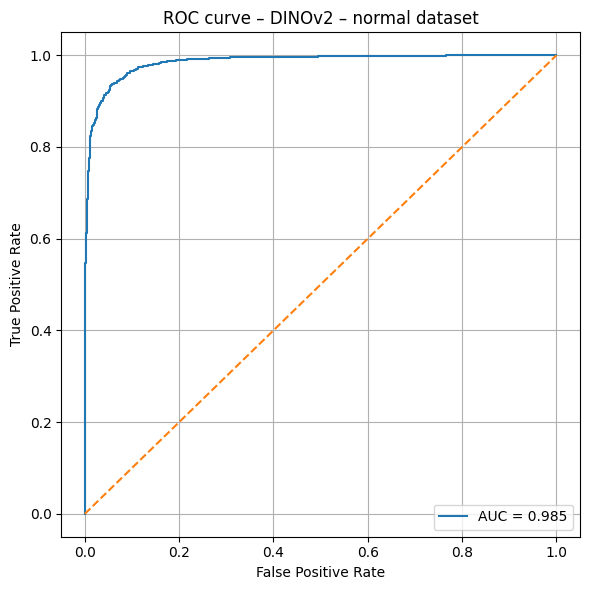

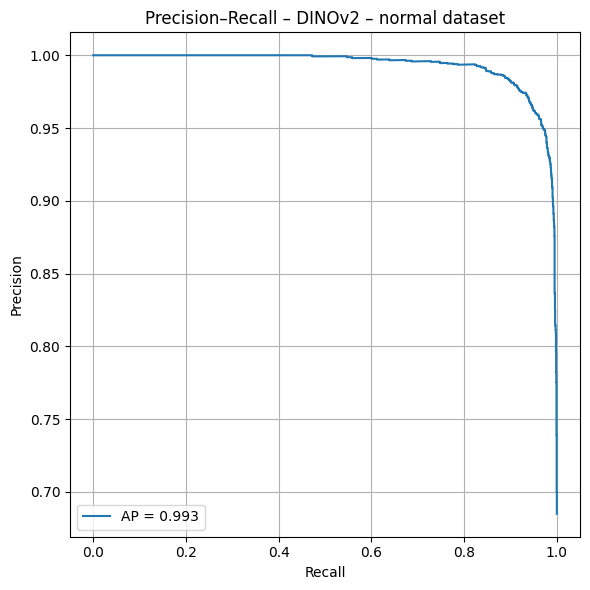

In [12]:
normal_summary = summarize_and_plot_results(
    normal_results,
    title_prefix="DINOv2 – normal dataset"
)

## 2. Données augmentées

In [13]:
augmented_results = run_experiment(
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,
    test_loader=aug_test_loader,
    run_dir="runs/dinov2_vits14_augmented",
    train_dataset=aug_train_dataset,
    experiment_name="DINOv2 on v3 augmented",
)

class counts -> neg=10149, pos=15223, class_weights=[1.0, 0.6666885614395142]
Model improved
Epoch 001 | train loss 0.3488 f1 0.8670 acc 0.8430 | val loss 0.2813 f1 0.9050 acc 0.8863 | 
Model improved
Epoch 002 | train loss 0.2716 f1 0.8998 acc 0.8812 | val loss 0.2599 f1 0.9068 acc 0.8897 | 
Model improved
Epoch 003 | train loss 0.2432 f1 0.9123 acc 0.8960 | val loss 0.2276 f1 0.9117 acc 0.8966 | 
Model improved
Epoch 004 | train loss 0.2194 f1 0.9221 acc 0.9077 | val loss 0.2270 f1 0.9185 acc 0.9031 | 
Model improved
Epoch 005 | train loss 0.1998 f1 0.9302 acc 0.9171 | val loss 0.2024 f1 0.9260 acc 0.9136 | 
Model improved
Epoch 006 | train loss 0.1644 f1 0.9426 acc 0.9318 | val loss 0.1923 f1 0.9400 acc 0.9281 | 
Model improved
Epoch 007 | train loss 0.1542 f1 0.9455 acc 0.9352 | val loss 0.1827 f1 0.9439 acc 0.9321 | 
Model improved
Epoch 008 | train loss 0.1443 f1 0.9508 acc 0.9415 | val loss 0.1740 f1 0.9443 acc 0.9330 | 
patience 1/5
Epoch 009 | train loss 0.1374 f1 0.9525 acc 0


===== DINOv2 – augmented dataset =====

Confusion matrix @0.5
[[1123  126]
 [ 105 2611]]

Classification report @0.5
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      1249
    Positive       0.95      0.96      0.96      2716

    accuracy                           0.94      3965
   macro avg       0.93      0.93      0.93      3965
weighted avg       0.94      0.94      0.94      3965


Confusion matrix @0.7
[[1173   76]
 [ 197 2519]]

Classification report @0.7
              precision    recall  f1-score   support

    Negative       0.86      0.94      0.90      1249
    Positive       0.97      0.93      0.95      2716

    accuracy                           0.93      3965
   macro avg       0.91      0.93      0.92      3965
weighted avg       0.93      0.93      0.93      3965



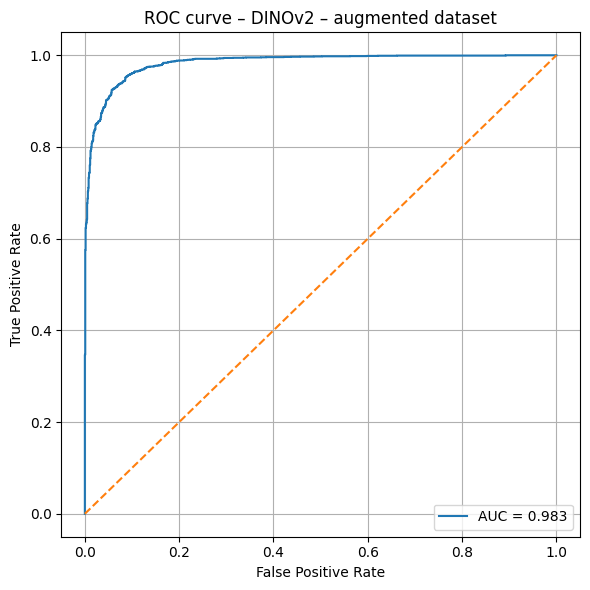

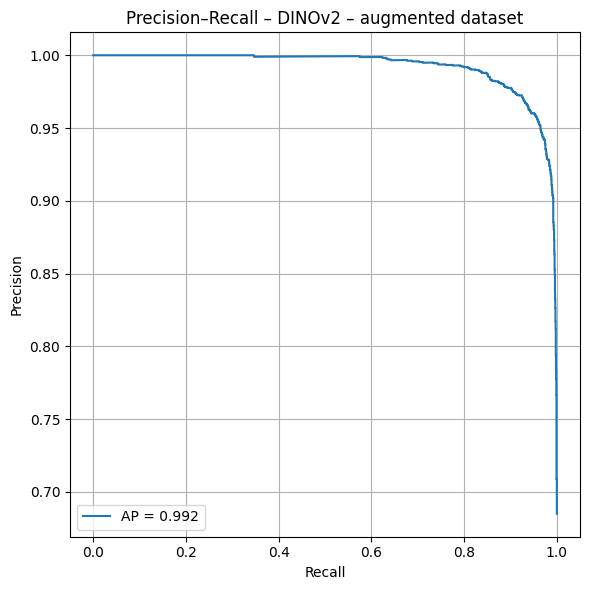

In [14]:
augmented_summary = summarize_and_plot_results(
    augmented_results,
    title_prefix="DINOv2 – augmented dataset"
)

In [15]:
print("Saved normal run in:", "runs/dinov2_vits14_normal")
print("Saved augmented run in:", "runs/dinov2_vits14_augmented")

Saved normal run in: runs/dinov2_vits14_normal
Saved augmented run in: runs/dinov2_vits14_augmented
